# Predicting NBA Home Team Wins

This project uses basketball data to predict whether the home team wins an NBA game.

The model is a **logistic regression classification model** because the response variable is binary:

- `1` = home team won
- `0` = home team lost

## Import Libraries

In [12]:
# import libraries
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

## Prepare Data

The project guidelines ask for a `wrangle` function. The function below reads the local data file, creates the target variable, creates a simple Elo difference predictor, removes columns that would not be useful for prediction, and drops missing values.

In [13]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Create binary target column
    df["home_win"] = (df["game_result"] == "W").astype(int)

    # Create simple predictor available before the game starts
    df["elo_diff"] = df["elo_i"] - df["opp_elo_i"]
    df["playoff_game"] = df["is_playoffs"].astype(int)

    # Drop columns that are identifiers, redundant, or leak
    drop_cols = [
        "game_id",
        "date_game",
        "fran_id",
        "opp_fran",
        "game_result",
        "is_playoffs",
    ]

    # Drop columns
    df.drop(columns = drop_cols, inplace=True)

    # Drop rows with missing values
    df.dropna(inplace = True)

    return df

In [14]:
df = wrangle("nba_home_2000_2015.csv")
print("df type:", type(df))
print("df shape:", df.shape)
df.head()

df type: <class 'pandas.core.frame.DataFrame'>
df shape: (20536, 9)


,year_id,seasongame,team_id,opp_id,elo_i,opp_elo_i,home_win,elo_diff,playoff_game
0,2000,1,CHH,ORL,1547.1558,1539.5251,1,7.6307,0
1,2000,1,DAL,GSW,1442.5089,1432.4757,1,10.0332,0
2,2000,1,DEN,PHO,1337.7113,1540.8169,1,-203.1056,0
3,2000,1,HOU,MIL,1507.2517,1508.7505,0,-1.4988,0
4,2000,1,LAC,SEA,1347.7274,1483.7173,0,-135.9899,0


Each row represents one NBA game from the home team's perspective. The target is `home_win`, where `1` means the home team won and `0` means the home team lost.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20536 entries, 0 to 20535
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year_id       20536 non-null  int64  
 1   seasongame    20536 non-null  int64  
 2   team_id       20536 non-null  object 
 3   opp_id        20536 non-null  object 
 4   elo_i         20536 non-null  float64
 5   opp_elo_i     20536 non-null  float64
 6   home_win      20536 non-null  int64  
 7   elo_diff      20536 non-null  float64
 8   playoff_game  20536 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.4+ MB


In [16]:
df.describe()

,year_id,seasongame,elo_i,opp_elo_i,home_win,elo_diff,playoff_game
count,20536.000000,20536.000000,20536.000000,20536.000000,20536.000000,20536.000000,20536.000000
mean,2007.511687,44.105132,1509.974368,1509.209530,0.603136,0.764838,0.063888
std,4.594876,25.595309,109.884282,109.736068,0.489259,150.361252,0.244559
min,2000.000000,1.000000,1155.439600,1156.343500,0.000000,-518.625700,0.000000
25%,2004.000000,22.000000,1431.466775,1431.241275,0.000000,-100.923700,0.000000
50%,2007.000000,44.000000,1513.246050,1511.748750,1.000000,1.280900,0.000000
75%,2011.000000,65.000000,1590.586125,1590.413675,1.000000,103.725950,0.000000
max,2015.000000,108.000000,1809.979100,1813.634900,1.000000,545.341800,1.000000


## Explore

First, I checked the distribution of the response variable. This tells us whether the classes are balanced and also gives us a baseline to compare the model against.

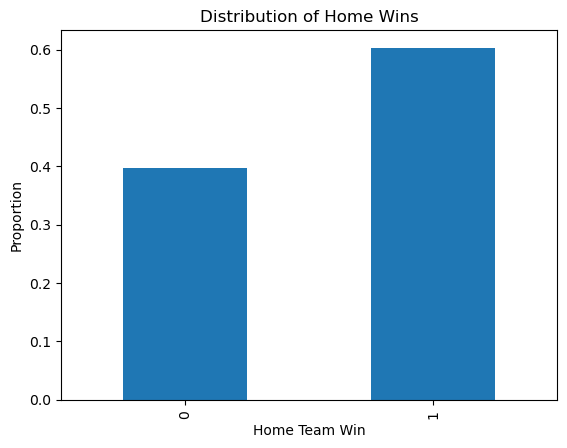

In [17]:
# Create bar chart of response variable
fig, ax = plt.subplots()
df["home_win"].value_counts(normalize = True).sort_index().plot(kind = "bar", ax = ax)
ax.set_xlabel("Home Team Win")
ax.set_ylabel("Proportion")
ax.set_title("Distribution of Home Wins");

The home team wins more often than it loses, so the baseline model will be a simple majority-class model that always predicts a home win.

Next, I looked at the distribution of `elo_diff`. Positive values mean the home team had a higher Elo rating than the away team before the game.

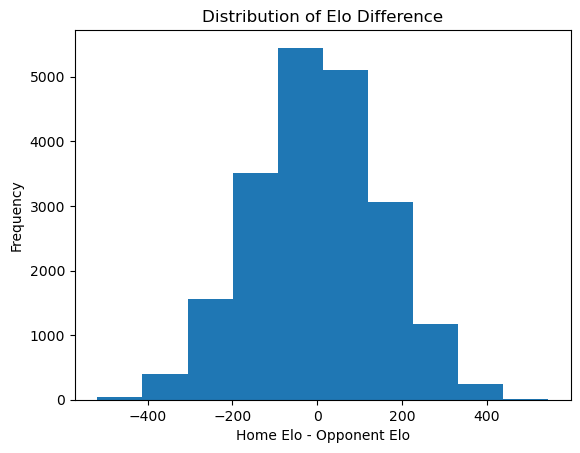

In [18]:
# Create histogram of Elo difference
fig, ax = plt.subplots()
ax.hist(df["elo_diff"])
ax.set_xlabel("Home Elo - Opponent Elo")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Elo Difference");

In [19]:
df["elo_diff"].describe()

count    20536.000000
mean         0.764838
std        150.361252
min       -518.625700
25%       -100.923700
50%          1.280900
75%        103.725950
max        545.341800
Name: elo_diff, dtype: float64

This boxplot compares Elo difference for games the home team lost and games the home team won.

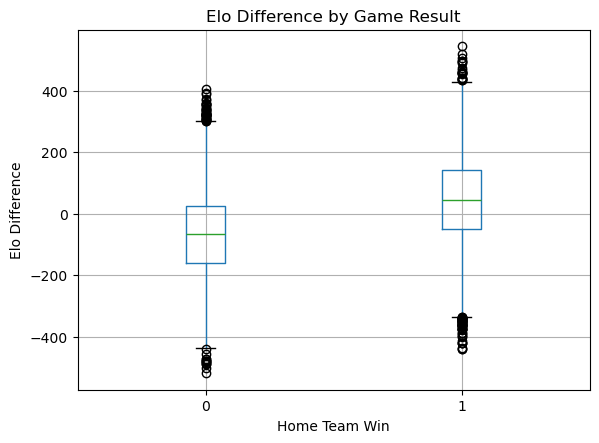

In [20]:
# Create boxplot of Elo difference by game result
fig, ax = plt.subplots()
df.boxplot(column = "elo_diff", by = "home_win", ax = ax)
ax.set_xlabel("Home Team Win")
ax.set_ylabel("Elo Difference")
ax.set_title("Elo Difference by Game Result")
fig.suptitle("");

The boxplot suggests that home teams with higher Elo ratings than their opponent are more likely to win. This makes `elo_diff` a useful feature for the model.

In [21]:
# Look at average home win rate by playoff status
df.groupby("playoff_game")["home_win"].mean()

playoff_game
0    0.600187
1    0.646341
Name: home_win, dtype: float64

## Split Data

The target is `home_win`. The remaining columns are the features used to predict the target. The test set is held out until final evaluation.

In [22]:
target = "home_win"
X = df.drop(columns = target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (20536, 8)
y shape: (20536,)


,year_id,seasongame,team_id,opp_id,elo_i,opp_elo_i,elo_diff,playoff_game
0,2000,1,CHH,ORL,1547.1558,1539.5251,7.6307,0
1,2000,1,DAL,GSW,1442.5089,1432.4757,10.0332,0
2,2000,1,DEN,PHO,1337.7113,1540.8169,-203.1056,0
3,2000,1,HOU,MIL,1507.2517,1508.7505,-1.4988,0
4,2000,1,LAC,SEA,1347.7274,1483.7173,-135.9899,0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16428, 8)
y_train shape: (16428,)
X_test shape: (4108, 8)
y_test shape: (4108,)


## Baseline

The baseline model predicts the most common class in the training set for every game.

In [24]:
baseline_acc = y_train.value_counts(normalize = True).max()
print("Baseline Accuracy:", round(baseline_acc, 3))

Baseline Accuracy: 0.603


## Build Model

In [25]:
# 1. Identify column types
categorical_cols = X_train.select_dtypes("object").columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['team_id', 'opp_id']
Numeric columns: ['year_id', 'seasongame', 'elo_i', 'opp_elo_i', 'elo_diff', 'playoff_game']


In [26]:
# 2. Combine preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown = "ignore"), categorical_cols),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy = "median")),
            ("scaler", StandardScaler())
        ]), numeric_cols)
    ]
)

# 3. Build final model pipeline
model = Pipeline([
    ("preprocessing", preprocessor),
    ("logisticregression", LogisticRegression(max_iter = 1000, random_state = 42))
])

model

,steps,"[('preprocessing', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
# Fit model
model.fit(X_train, y_train)

# Check model is fitted
check_is_fitted(model)

## Evaluate

Now I evaluated the model on both the training set and the final test set.

In [28]:
training_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("Training Accuracy:", round(training_acc, 3))
print("Test Accuracy:", round(test_acc, 3))
print("Baseline Accuracy:", round(baseline_acc, 3))

Training Accuracy: 0.674
Test Accuracy: 0.669
Baseline Accuracy: 0.603


In [29]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, -1]

print("Test Precision:", round(precision_score(y_test, y_pred), 3))
print("Test Recall:", round(recall_score(y_test, y_pred), 3))
print("Test AUC:", round(roc_auc_score(y_test, y_pred_proba), 3))

Test Precision: 0.694
Test Recall: 0.808
Test AUC: 0.712


In [30]:
# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.46      0.52      1630
           1       0.69      0.81      0.75      2478

    accuracy                           0.67      4108
   macro avg       0.65      0.63      0.64      4108
weighted avg       0.66      0.67      0.66      4108



The model performs better than the baseline, which means the predictors add useful information besides simply predicting that the home team always wins.

## Communicate Results

The confusion matrix shows how many games the model classified correctly and incorrectly.

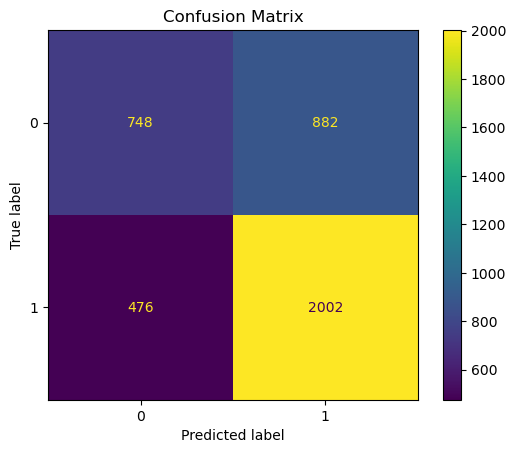

In [31]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix");

The ROC curve shows how well the model separates home wins from home losses across different probability thresholds.

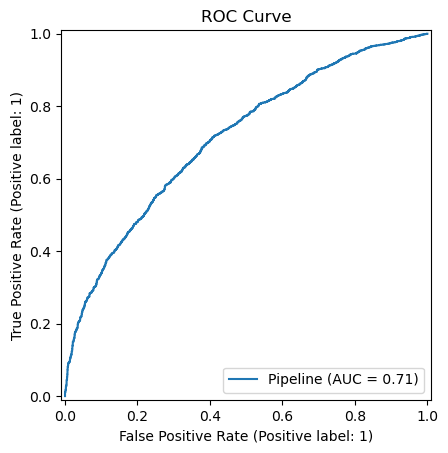

In [32]:
# Plot ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve");

Finally, I looked at the logistic regression coefficients. Positive coefficients increase the predicted probability of a home win, while negative coefficients decrease it.

In [33]:
# Get feature names from preprocessing step
features = model.named_steps["preprocessing"].get_feature_names_out()

# Extract coefficients from logistic regression model
coefs = model.named_steps["logisticregression"].coef_[0]

# Create a series with feature names and coefficients
coef_series = pd.Series(coefs, index = features).sort_values()
coef_series.tail(10)

cat__opp_id_WAS     0.178397
cat__opp_id_DEN     0.187368
cat__team_id_NOP    0.190620
cat__team_id_DEN    0.203727
cat__team_id_OKC    0.214821
cat__team_id_UTA    0.220489
cat__team_id_NOK    0.243731
cat__opp_id_ATL     0.253248
num__elo_i          0.327130
num__elo_diff       0.420823
dtype: float64

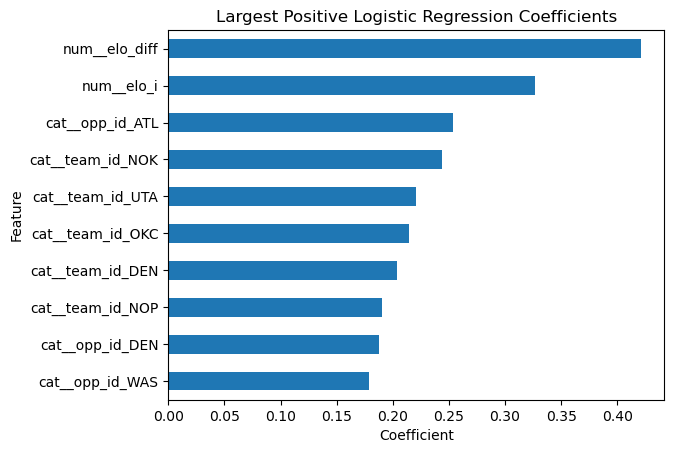

In [34]:
# Plot 10 largest positive coefficients
fig, ax = plt.subplots()
coef_series.tail(10).plot(kind = "barh", ax = ax)
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")
ax.set_title("Largest Positive Logistic Regression Coefficients");

## Conclusion

This project used a simple basketball dataset and a logistic regression model to predict NBA home team wins. The most important idea is that pre-game information, especially Elo rating difference, helps predict whether the home team wins. The final model beats the majority-class baseline on the test set, so it provides useful predictive value while still being easy to explain.